In [25]:
import time

import numpy as np

from scipy import special, integrate, spatial

import sympy
from sympy.printing.numpy import SciPyPrinter

from astropy import units as u

In [26]:
from matplotlib import pyplot as plt 

In [27]:
BN_ICOEFFS = [2, -1/3, 4/405, 46/25515, 131/1148175, -2194697/30690717750]

def f_bn(n):
    """
    Ciotti and Bertin 99, valid for n >~ 0.36
    """
    return np.sum([C*n**(1-i) for i, C in enumerate(BN_ICOEFFS)], axis=0)

def sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return Ie * np.exp(-bn*((R/Re)**(1/n)-1))

def log_sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return np.log(Ie) - bn*((R/Re)**(1/n)-1)

# Analytic inversion of the sersic function

In [28]:
Ie, R, Re, bn, n, x, U, γ = sympy.symbols('I_e, R, R_e, b_n, n, x, U, γ', real=True, positive=True)

sersic = Ie*sympy.exp(-bn*((R/Re)**(1/n)-1))
sersic

I_e*exp(-b_n*((R/R_e)**(1/n) - 1))

In [29]:
integ = sympy.integrate(sersic*R, (R, 0, x)).simplify()
integ

I_e*R_e**2*n*exp(b_n)*lowergamma(2*n, b_n*x**(1/n)/R_e**(1/n))/b_n**(2*n)

In [30]:
finteg = sympy.lambdify((x, Re, n, bn, Ie), integ)
SciPyPrinter().doprint(integ).replace('numpy.','np.').replace('scipy.special', 'special').replace('_','')

'Ie*Re**2*bn**(-2*n)*n*np.exp(bn)*special.gamma(2*n)*special.gammainc(2*n, Re**(-1/n)*bn*x**(n**(-1.0)))'

In [7]:
# raises NotImplementedError
#sympy.solve(integ - U, x)

We can live with that, since scipy has an inverse lower gamma, we can just solve for the lowergamma instead.

In [8]:
gammal = integ.args[-1]
assert isinstance(gammal, sympy.lowergamma)  # it should always be the last arg?

solns = sympy.solve(integ.subs({gammal: γ}) - U, γ)
assert len(solns) == 1
soln = solns[0]
sympy.Eq(γ, soln)

Eq(γ, U*b_n**(2*n)*exp(-b_n)/(I_e*R_e**2*n))

In [9]:
SciPyPrinter().doprint(soln).replace('numpy.','np.')

'U*b_n**(2*n)*np.exp(-b_n)/(I_e*R_e**2*n)'

In [10]:
gammal

lowergamma(2*n, b_n*x**(1/n)/R_e**(1/n))

Important: the scipy gamma is slighly different from the sympy gamma!:

In [11]:
SciPyPrinter().doprint(gammal).replace('scipy.special', 'special')

'special.gamma(2*n)*special.gammainc(2*n, R_e**(-1/n)*b_n*x**(n**(-1.0)))'

In [12]:
gammal.args[1]

b_n*x**(1/n)/R_e**(1/n)

In [13]:
def sersic_distribution(U, Re, n, Router=np.inf):
    bn = f_bn(n)

    Iemax = 1/finteg(Router, Re, n, bn, 1)

    sympy_gamma = U*bn**(2*n)*np.exp(-bn)/(Iemax*Re**2*n)
    gamma_arg = special.gammaincinv(2*n, sympy_gamma / special.gamma(2*n))
    return Re*(gamma_arg/bn)**n

sersic_distribution(.5, 1, 2)

np.float64(0.9999974417319889)

# Mock galaxy generators

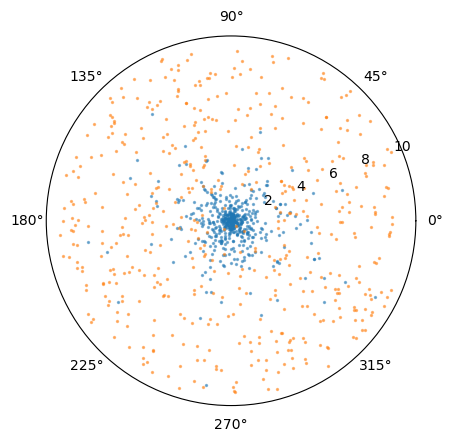

In [14]:
def sersic_plus_uniform_circle(ntotal, fbkg, n, Re=1, Router=10, polar_out=True):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    r_bkg = np.sqrt(np.random.rand(nbkg))*Router
    θ_bkg = np.random.rand(nbkg)*2*np.pi

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi

    r, θ = np.concatenate([r_fg, r_bkg]), np.concatenate([θ_fg, θ_bkg])

    if polar_out:
        return r, θ, nfg
    else:
        x = r*np.cos(θ)
        y = r*np.sin(θ)
        return x, y, nfg

r, θ, nfg = sersic_plus_uniform_circle(1000, .5, 2, Re=1)

plt.polar()
plt.scatter(θ[:nfg], r[:nfg], s=2, alpha=.5)
plt.scatter(θ[-nfg:], r[-nfg:], s=2, alpha=.5)
plt.grid(False);

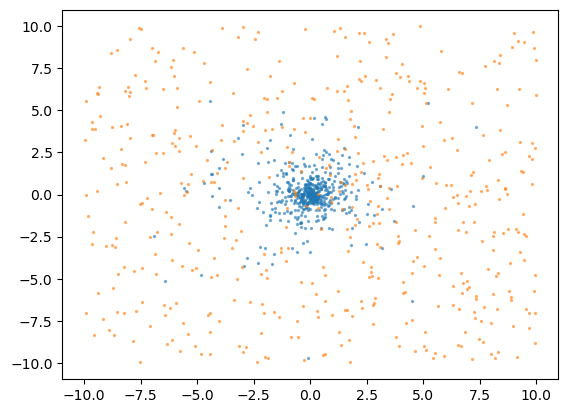

In [15]:
def sersic_plus_uniform_box(ntotal, fbkg, n, Re=1, Router=10):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    x_bkg = np.random.rand(nbkg)*Router*2 - Router
    y_bkg = np.random.rand(nbkg)*Router*2 - Router

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi
    
    x_fg = r_fg*np.cos(θ_fg)
    y_fg = r_fg*np.sin(θ_fg)

    return np.concatenate([x_fg, x_bkg]), np.concatenate([y_fg, y_bkg]), nfg

x, y, nfg = sersic_plus_uniform_box(1000, .5, 2, Re=1)

plt.scatter(x[:nfg], y[:nfg], s=2, alpha=.5)
plt.scatter(x[-nfg:], y[-nfg:], s=2, alpha=.5)

# Compute the true sersic integrals over a box or circular survey

In [16]:
def circle_sersic_integral(n, Re, Router):
    return integrate.quad(lambda r:r*sersic_profile(r, Ie=1, Re=Re, n=n)*2*np.pi, 0, Router)

circle_sersic_integral(2, 1, 1)[0]/circle_sersic_integral(2, 1, np.inf)[0], circle_sersic_integral(2, 1, np.inf)

(0.5000009854915142, (16.31087363948515, 5.56194486023287e-08))

In [17]:
def box_sersic_integral(n, Re, left, right, bottom, top):
    return integrate.dblquad(lambda y,x:sersic_profile(np.hypot(x, y), Ie=1, Re=Re, n=n), 
                             left, right, 
                             lambda x:bottom, lambda x:top)

box_sersic_integral(2, 1, -10, 10, -10, 10)

(16.277646704888625, 1.644423664730766e-07)

# Creating hulls from data points

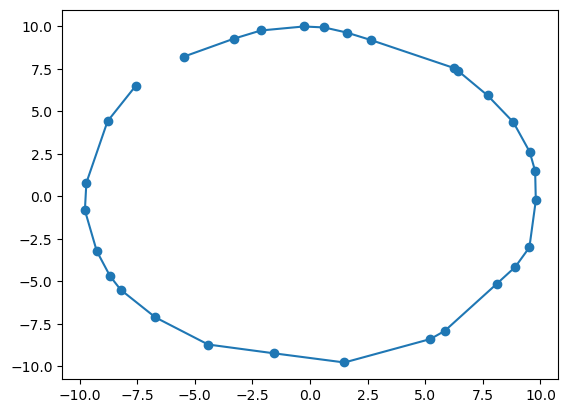

In [40]:
x, y, _ = sersic_plus_uniform_circle(1000, .5, 2, Re=1, polar_out=False)
hull_circ = spatial.ConvexHull(np.array((x, y)).T)
plt.plot(*hull_circ.points[hull_circ.vertices].T, 'o-')

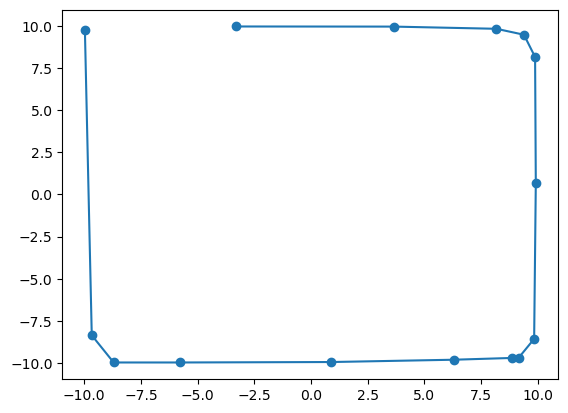

In [41]:
x, y, _ = sersic_plus_uniform_box(1000, .5, 2, Re=1)
hull_box = spatial.ConvexHull(np.array((x, y)).T)
plt.plot(*hull_box.points[hull_box.vertices].T, 'o-')

# Integrals from hulls

Using the greens theorem approach from [greenstheorem_sersic.ipynb](greenstheorem_sersic.ipynb). Re-derive here with the added scaling factors:

In [42]:
Ie, R, Re, bn, n = sympy.symbols('I_e, R, R_e, b_n, n', real=True, positive=True)
θ, x, y, Δx, Δy = sympy.symbols('θ, x, y, Δx, Δy', real=True)

In [43]:
Fr = R-R
Fθ = sympy.integrate(R*sympy.exp(-bn*((R/Re)**(1/n)-1)), R)/R

Fθ.simplify()

R_e**2*n*exp(b_n)*lowergamma(2*n, R**(1/n)*b_n/R_e**(1/n))/(R*b_n**(2*n))

In [44]:
curlp = Ie*(sympy.diff(R*Fθ, R)  - sympy.diff(Fr, θ))/R
curlp.simplify()

I_e*exp(-R**(1/n)*b_n/R_e**(1/n) + b_n)

In [45]:
assert curlp.simplify() == sersic.simplify()

In [46]:
Fx = (Fr*x/R - Fθ*y/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})
Fy = (Fr*y/R + Fθ*x/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})

In [47]:
cartsoln = (Fx* Δx + Fy* Δy).simplify()
cartsoln

R_e**2*n*(x*Δy - y*Δx)*exp(b_n)*lowergamma(2*n, b_n*(x**2 + y**2)**(1/(2*n))/R_e**(1/n))/(b_n**(2*n)*(x**2 + y**2))

In [48]:
SciPyPrinter().doprint(cartsoln).replace('scipy.special.', 'special.').replace('numpy.', 'np.')

'R_e**2*b_n**(-2*n)*n*(x*Δy - y*Δx)*np.exp(b_n)*special.gamma(2*n)*special.gammainc(2*n, R_e**(-1/n)*b_n*(x**2 + y**2)**((1/2)/n))/(x**2 + y**2)'

In [49]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

 First lets make sure we understand the scipy convex hull/qhull data format

In [50]:
vertxys = hull_circ.points[hull_circ.vertices].T
edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), 1000).T

int_segments = []
for x,y in edgexys:
    dx = x[1]-x[0]
    dy = y[1]-y[0]
    
    int_segments.append(dimensionless_path_integrand(x, y, dx, dy, Re=1, n=2))
np.array(int_segments), np.sum(int_segments)

(array([0.63524564, 0.99521557, 0.42883275, 0.64974895, 0.41667691,
        0.24178336, 0.58390335, 0.74171342, 0.77715153, 0.83045035,
        1.04804012, 0.20699997, 0.95944944, 0.32865352, 0.33944759,
        0.72657426, 0.45475798, 0.30413097, 0.49403837, 0.51009244,
        0.5167295 , 0.05683514, 1.06912646, 0.30231678, 0.26376092,
        0.23210646, 0.48664866, 0.32742476, 0.63529098, 0.70705885]),
 np.float64(16.270204992132545))

In [101]:
def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

sersic_integrate_hull(hull_circ, 1000, n=2, Re=1), sersic_integrate_hull(hull_box, 1000, n=2, Re=1)

(np.float64(16.270204992132545), np.float64(16.29040928293739))

Math works!  Huzzah! Now some accuracy/timing tests:

In [102]:
sersic_integrate_hull(hull_circ, 10000, n=2, Re=1)

np.float64(16.255742778673326)

In [103]:
sersic_integrate_hull(hull_circ, 100000, n=2, Re=1)

np.float64(16.25429797148282)

In [104]:
sersic_integrate_hull(hull_circ, 500000, n=2, Re=1)

np.float64(16.254169556427016)

In [105]:
%timeit sersic_integrate_hull(hull_circ, 1000, n=2, Re=1)
%timeit sersic_integrate_hull(hull_circ, 10000, n=2, Re=1)
%timeit sersic_integrate_hull(hull_circ, 100000, n=2, Re=1)
%timeit sersic_integrate_hull(hull_circ, 500000, n=2, Re=1)

1.99 ms ± 12.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
16.6 ms ± 185 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
174 ms ± 189 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.2 s ± 3.31 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
